<div style="background: linear-gradient(135deg, #0f172a, #1e293b); color:white; padding:25px; border-radius:10px; 
            text-align:center; font-family:'Segoe UI', sans-serif;">

  <h1 style="margin-bottom:8px;">Market Sentiment Analysis from Tweets</h1>
  <h3 style="margin-top:0; font-style:italic; font-weight:normal; color:#94a3b8;">
    Feature Engineering - Text Representation Techniques
  </h3>

  <hr style="width:60%; border:1px solid #475569; margin:15px auto;">

  <p style="margin:5px 0; font-size:15px;">
    <b>Group Project</b> - Text Mining (2025/2026)
  </p>
  <p style="margin:0; font-size:13px; color:#cbd5e1;">
    Master in Data Science and Advanced Analytics - Nova Information Management School
  </p>
</div>

<br>

<div style="background-color:#1e293b; color:#e2e8f0; padding:15px 20px; border-left:5px solid #475569; 
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">

  <b>Notebook Description</b><br>
  Implements and compares four text representation techniques - Bag of Words, TF-IDF, Word2Vec, and GloVe - fitted exclusively on the training split to prevent data leakage. Loads preprocessed data from the pickle produced by <code>02_preprocessing.ipynb</code>.
</div>

**<h3>Table of Contents</h3>**

1. [Setup](#1-setup)
2. [Load Preprocessed Data](#2-load)
3. [Bag of Words (BoW)](#3-bow)
4. [TF-IDF](#4-tfidf)
5. [Word2Vec](#5-w2v)
6. [Pre-trained Embeddings - GloVe Twitter](#6-glove)
7. [Representation Comparison](#7-comparison)
8. [Save Feature Matrices](#8-save)

<div id="1-setup" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">
    1. Setup
  </h2>
</div>

In [1]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.decomposition import PCA

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec
import gensim.downloader
from tensorflow.keras.preprocessing.sequence import pad_sequences as keras_pad

sns.set_theme(style='whitegrid')

LABEL_NAMES = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
PALETTE     = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}

<div id="2-load" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">
    2. Load Preprocessed Data
  </h2>
</div>

In [2]:
with open('../data/processed_splits.pkl', 'rb') as f:
    data = pickle.load(f)

x_train_lem  = data['x_train_lem']
x_val_lem    = data['x_val_lem']
test_lem     = data['test_lem']
x_train_stem = data['x_train_stem']
x_val_stem   = data['x_val_stem']
test_stem    = data['test_stem']
y_train      = data['y_train']
y_val        = data['y_val']

print(f'Train : {len(x_train_lem):,} tweets')
print(f'Val   : {len(x_val_lem):,} tweets')
print(f'Test  : {len(test_lem):,} tweets')

Train : 7,634 tweets
Val   : 1,909 tweets
Test  : 2,388 tweets


<div id="3-bow" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">
    3. Bag of Words (BoW)
  </h2>
</div>

BoW represents each document as a vector over the full vocabulary. Each position indicates whether (or how often) a word appears.

| Variant | Value per word | Captures frequency? |
|---|---|---|
| **Binary** | 1 if present, 0 otherwise | No |
| **Count** | raw term count | Yes |

The vectoriser is **fitted on the training set only** - the vocabulary is fixed from training and applied to validation with `.transform()`.

### 3.1 Binary BoW

In [3]:
# Lemmatized
bow_binary_lem  = CountVectorizer(binary=True)
x_train_bow_binary_lem  = bow_binary_lem.fit_transform(x_train_lem)
x_val_bow_binary_lem    = bow_binary_lem.transform(x_val_lem)
test_bow_binary_lem     = bow_binary_lem.transform(test_lem)

# Stemmed
bow_binary_stem = CountVectorizer(binary=True)
x_train_bow_binary_stem = bow_binary_stem.fit_transform(x_train_stem)
x_val_bow_binary_stem   = bow_binary_stem.transform(x_val_stem)
test_bow_binary_stem    = bow_binary_stem.transform(test_stem)

print(f'{"Variant":<10} {"Vocab":>8}  {"Train shape"}')
print('-' * 40)
print(f'{"Lem":<10} {len(bow_binary_lem.get_feature_names_out()):>8,}  {x_train_bow_binary_lem.shape}')
print(f'{"Stem":<10} {len(bow_binary_stem.get_feature_names_out()):>8,}  {x_train_bow_binary_stem.shape}')

density = x_train_bow_binary_lem.nnz / (x_train_bow_binary_lem.shape[0] * x_train_bow_binary_lem.shape[1]) * 100
print(f'\nMatrix density (lem) : {density:.3f}%  (sparse - most entries are 0)')

Variant       Vocab  Train shape
----------------------------------------
Lem          11,113  (7634, 11113)
Stem          9,420  (7634, 9420)

Matrix density (lem) : 0.075%  (sparse - most entries are 0)


Just to make sure before going forward, a quick sanity check:

In [4]:
idx = 0
vec_lem  = x_train_bow_binary_lem[idx].toarray().flatten()
vec_stem = x_train_bow_binary_stem[idx].toarray().flatten()

words_lem  = list(bow_binary_lem.get_feature_names_out()[np.where(vec_lem == 1)[0]])
words_stem = list(bow_binary_stem.get_feature_names_out()[np.where(vec_stem == 1)[0]])

print(f'Tweet (lem) : {x_train_lem.iloc[idx]}')
print(f'Words present ({len(words_lem)}): {words_lem}')
print()
print(f'Tweet (stem): {x_train_stem.iloc[idx]}')
print(f'Words present ({len(words_stem)}): {words_stem}')

Tweet (lem) : nasdaq price 600m <pct> senior note
Words present (6): ['600m', 'nasdaq', 'note', 'pct', 'price', 'senior']

Tweet (stem): nasdaq price 600m <pct> senior note
Words present (6): ['600m', 'nasdaq', 'note', 'pct', 'price', 'senior']


### 3.2 Count BoW

As stated earlier, a Counted BoW is also being used because it captures frequency.

In [5]:
# Lemmatized
bow_count_lem  = CountVectorizer(binary=False)
x_train_bow_count_lem  = bow_count_lem.fit_transform(x_train_lem)
x_val_bow_count_lem    = bow_count_lem.transform(x_val_lem)
test_bow_count_lem     = bow_count_lem.transform(test_lem)

# Stemmed
bow_count_stem = CountVectorizer(binary=False)
x_train_bow_count_stem = bow_count_stem.fit_transform(x_train_stem)
x_val_bow_count_stem   = bow_count_stem.transform(x_val_stem)
test_bow_count_stem    = bow_count_stem.transform(test_stem)

print(f'{"Variant":<10} {"Vocab":>8}  {"Train shape"}')
print('-' * 40)
print(f'{"Lem":<10} {len(bow_count_lem.get_feature_names_out()):>8,}  {x_train_bow_count_lem.shape}')
print(f'{"Stem":<10} {len(bow_count_stem.get_feature_names_out()):>8,}  {x_train_bow_count_stem.shape}')

Variant       Vocab  Train shape
----------------------------------------
Lem          11,113  (7634, 11113)
Stem          9,420  (7634, 9420)


In [6]:
idx = 104
binary_vec = x_train_bow_binary_lem[idx].toarray().flatten()
count_vec  = x_train_bow_count_lem[idx].toarray().flatten()

present = np.where(count_vec > 0)[0]

print(f'Tweet (lem) : {x_train_lem.iloc[idx]}')
print()
print(f'{"Word":<20} {"Binary":<10} {"Count":<10}')
print('-' * 40)
for i in present:
    word = bow_count_lem.get_feature_names_out()[i]
    print(f'{word:<20} {int(binary_vec[i]):<10} {int(count_vec[i]):<10}')

Tweet (lem) : north korean leader kim jong un supervised military drill urge north korea cease military acti

Word                 Binary     Count     
----------------------------------------
acti                 1          1         
cease                1          1         
drill                1          1         
jong                 1          1         
kim                  1          1         
korea                1          1         
korean               1          1         
leader               1          1         
military             1          2         
north                1          2         
supervised           1          1         
un                   1          1         
urge                 1          1         


Both variants produce identical vocabularies. Binary BoW ignores how many times a word repeats - useful when term frequency is not informative (e.g. a tweet that says `"beats"` once vs twice carries similar sentiment). Count BoW is more informative when repetition signals emphasis, but it also amplifies common words regardless of their discriminative value - which TF-IDF addresses.

**Stemming reduces vocabulary size by ~15%** (11,113 -> 9,420) by collapsing inflected forms into a common root - `"earnings"`, `"earned"`, `"earns"` all become `"earn"`. This reduces sparsity but may merge words that carry distinct sentiment signals.

<div id="4-tfidf" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">
    4. TF-IDF
  </h2>
</div>

TF-IDF weights each term by how often it appears in a document (**TF**) relative to how rare it is across the corpus (**IDF**). Words that appear in every document (e.g. `"stock"`) get a low IDF and are effectively downweighted. The main goal is to treat rare words as more informative and important than common words.

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\frac{N}{1 + \text{df}(t)}$$

Two variants are compared:
- **Unigrams** - single words
- **Bigrams** - includes word pairs (`"price target"`, `"earnings beat"`)

### 4.1 TF-IDF Unigrams

In [7]:
# Lemmatized
tfidf_uni_lem  = TfidfVectorizer(ngram_range=(1, 1), max_df=0.9, min_df=2)
x_train_tfidf_uni_lem  = tfidf_uni_lem.fit_transform(x_train_lem)
x_val_tfidf_uni_lem    = tfidf_uni_lem.transform(x_val_lem)
test_tfidf_uni_lem     = tfidf_uni_lem.transform(test_lem)

# Stemmed
tfidf_uni_stem = TfidfVectorizer(ngram_range=(1, 1), max_df=0.9, min_df=2)
x_train_tfidf_uni_stem = tfidf_uni_stem.fit_transform(x_train_stem)
x_val_tfidf_uni_stem   = tfidf_uni_stem.transform(x_val_stem)
test_tfidf_uni_stem    = tfidf_uni_stem.transform(test_stem)

print(f'{"Variant":<10} {"Vocab":>8}  {"Train shape"}')
print('-' * 40)
print(f'{"Lem":<10} {len(tfidf_uni_lem.get_feature_names_out()):>8,}  {x_train_tfidf_uni_lem.shape}')
print(f'{"Stem":<10} {len(tfidf_uni_stem.get_feature_names_out()):>8,}  {x_train_tfidf_uni_stem.shape}')

# Top unigrams by mean TF-IDF score across training documents
feature_names = tfidf_uni_lem.get_feature_names_out()
mean_tfidf    = np.asarray(x_train_tfidf_uni_lem.mean(axis=0)).flatten()
top_idx       = np.argsort(mean_tfidf)[-15:][::-1]

print()
print('Top 15 unigrams by mean TF-IDF (lem):')
for i in top_idx:
    print(f'  {feature_names[i]:<25} mean tfidf = {mean_tfidf[i]:.4f}')

Variant       Vocab  Train shape
----------------------------------------
Lem           5,076  (7634, 5076)
Stem          4,501  (7634, 4501)

Top 15 unigrams by mean TF-IDF (lem):
  hashtag                   mean tfidf = 0.0412
  num                       mean tfidf = 0.0366
  ticker                    mean tfidf = 0.0349
  money                     mean tfidf = 0.0263
  stock                     mean tfidf = 0.0190
  quarter                   mean tfidf = 0.0164
  pct                       mean tfidf = 0.0163
  report                    mean tfidf = 0.0131
  result                    mean tfidf = 0.0125
  up                        mean tfidf = 0.0122
  market                    mean tfidf = 0.0117
  dividend                  mean tfidf = 0.0103
  price                     mean tfidf = 0.0102
  earnings                  mean tfidf = 0.0096
  new                       mean tfidf = 0.0093


TF-IDF unigrams fitted on lemmatized and stemmed variants with `max_df=0.9` (drops terms appearing in >90% of tweets) and `min_df=2` (drops terms that appear in only one document), yielding ~5k features vs ~11k in raw BoW. The vectorizer is fit only on the training set and applied to validation and test to prevent leakage.

### 4.2 TF-IDF Bigrams

In [8]:
# Lemmatized
tfidf_bi_lem  = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=2)
x_train_tfidf_bi_lem  = tfidf_bi_lem.fit_transform(x_train_lem)
x_val_tfidf_bi_lem    = tfidf_bi_lem.transform(x_val_lem)
test_tfidf_bi_lem     = tfidf_bi_lem.transform(test_lem)

# Stemmed
tfidf_bi_stem = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=2)
x_train_tfidf_bi_stem = tfidf_bi_stem.fit_transform(x_train_stem)
x_val_tfidf_bi_stem   = tfidf_bi_stem.transform(x_val_stem)
test_tfidf_bi_stem    = tfidf_bi_stem.transform(test_stem)

print(f'{"Variant":<10} {"Vocab":>8}  {"Train shape"}')
print('-' * 40)
print(f'{"Lem":<10} {len(tfidf_bi_lem.get_feature_names_out()):>8,}  {x_train_tfidf_bi_lem.shape}')
print(f'{"Stem":<10} {len(tfidf_bi_stem.get_feature_names_out()):>8,}  {x_train_tfidf_bi_stem.shape}')

# Top bigrams by mean TF-IDF score across training documents
import numpy as np
bi_features  = tfidf_bi_lem.get_feature_names_out()
mean_tfidf   = np.asarray(x_train_tfidf_bi_lem.mean(axis=0)).flatten()
bigram_mask  = np.array([' ' in f for f in bi_features])
bigram_scores = mean_tfidf * bigram_mask
top_idx      = np.argsort(bigram_scores)[-15:][::-1]

print()
print('Top 15 bigrams by mean TF-IDF (lem):')
for i in top_idx:
    print(f'  {bi_features[i]:<30} mean tfidf = {bigram_scores[i]:.4f}')

Variant       Vocab  Train shape
----------------------------------------
Lem          10,468  (7634, 10468)
Stem         10,151  (7634, 10151)

Top 15 bigrams by mean TF-IDF (lem):
  hashtag hashtag                mean tfidf = 0.0202
  ticker ticker                  mean tfidf = 0.0084
  quarter result                 mean tfidf = 0.0070
  report quarter                 mean tfidf = 0.0056
  num num                        mean tfidf = 0.0054
  hedge fund                     mean tfidf = 0.0049
  declares money                 mean tfidf = 0.0048
  money dividend                 mean tfidf = 0.0048
  up pct                         mean tfidf = 0.0038
  money billion                  mean tfidf = 0.0037
  stock market                   mean tfidf = 0.0035
  price target                   mean tfidf = 0.0034
  money money                    mean tfidf = 0.0029
  quarter earnings               mean tfidf = 0.0028
  beat money                     mean tfidf = 0.0027


Bigrams like `"price target"` or `"quarter earnings"` capture sentiment-rich phrases that unigrams split into individual tokens. The vocabulary grows substantially with bigrams - this increases expressiveness but also the risk of overfitting on small datasets.

**Analysis of top terms by mean TF-IDF:**

The unigram ranking is dominated by sentinel tokens (`<hashtag>`, `<num>`, `<ticker>`, `<money>`) - confirming that the preprocessing substitutions are working and these placeholders are common across the corpus. Financial terms like `stock`, `quarter`, `earnings`, `dividend` and `price` appear consistently, indicating they carry discriminative weight across many tweets.

The bigram ranking shows `"hashtag hashtag"` and `"ticker ticker"` at the top - tweets with multiple hashtags or tickers are frequent enough to dominate. More informative pairs like `"price target"`, `"quarter result"` and `"quarter earnings"` rank lower but are semantically meaningful for sentiment classification.

<div id="5-w2v" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">
    5. Word2Vec
  </h2>
</div>

Word2Vec trains a shallow neural network to produce dense word vectors that encode semantic meaning. Two architectures exist:

| Architecture | Training objective | `sg` parameter |
|---|---|---|
| **CBOW** (Continuous Bag of Words) | Predict **centre word** from context | `sg=0` |
| **Skip-Gram** | Predict **context words** from centre | `sg=1` |

Skip-Gram works better for rare words and smaller datasets; CBOW is faster and slightly better for frequent words.

The model is trained on the **training corpus only**. Document vectors are obtained by averaging the word vectors of all tokens in each tweet.

### 5.1 Train Word2Vec (CBOW and Skip-Gram)

Four Word2Vec models are trained: CBOW and Skip-Gram, on both the lemmatized and stemmed variants. All use the same hyperparameters (100 dimensions, window=5, min_count=2).

In [9]:
W2V_DIM    = 100
W2V_WINDOW = 5
W2V_MIN    = 2

def train_w2v(tokens, sg, seed=42):
    return Word2Vec(sentences=tokens, vector_size=W2V_DIM, window=W2V_WINDOW,
                    min_count=W2V_MIN, sg=sg, seed=seed, workers=4)

train_tokens_lem  = [text.split() for text in x_train_lem]
train_tokens_stem = [text.split() for text in x_train_stem]

w2v_cbow_lem  = train_w2v(train_tokens_lem,  sg=0)
w2v_sg_lem    = train_w2v(train_tokens_lem,  sg=1)
w2v_cbow_stem = train_w2v(train_tokens_stem, sg=0)
w2v_sg_stem   = train_w2v(train_tokens_stem, sg=1)

print(f'{"Model":<20} {"Vocab":>8}')
print('-' * 30)
print(f'{"CBOW lem":<20} {len(w2v_cbow_lem.wv):>8,}')
print(f'{"Skip-Gram lem":<20} {len(w2v_sg_lem.wv):>8,}')
print(f'{"CBOW stem":<20} {len(w2v_cbow_stem.wv):>8,}')
print(f'{"Skip-Gram stem":<20} {len(w2v_sg_stem.wv):>8,}')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Model                   Vocab
------------------------------
CBOW lem                5,170
Skip-Gram lem           5,170
CBOW stem               4,587
Skip-Gram stem          4,587


### 5.2 Explore the Embedding Space

In [10]:
probe_bearish = ['miss', 'eps', 'downgrade', 'cut', 'hedge']
probe_bullish = ['beat', 'price', 'target', 'raised', 'upgrade']
probe_neutral = ['dividend', 'earnings', 'conference', 'transcript', 'declares']

for group_name, probe_words in [('Bearish', probe_bearish), 
                                  ('Bullish', probe_bullish), 
                                  ('Neutral', probe_neutral)]:
    print(f'\n--- {group_name} ---')
    print(f"{'Word':<12} {'CBOW (lem)':<35} {'Skip-Gram (lem)':<35}")
    print('-' * 90)
    for word in probe_words:
        try:
            cbow_sim = [w for w, _ in w2v_cbow_lem.wv.most_similar(word, topn=3)]
            sg_sim   = [w for w, _ in w2v_sg_lem.wv.most_similar(word, topn=3)]
            print(f'{word:<12} {str(cbow_sim):<35} {str(sg_sim):<35}')
        except KeyError:
            print(f'{word:<12} not in vocabulary')


--- Bearish ---
Word         CBOW (lem)                          Skip-Gram (lem)                    
------------------------------------------------------------------------------------------
miss         ['eps', 'revenue', 'beat']          ['beat', 'revenue', 'eps']         
eps          ['revenue', 'miss', 'beat']         ['revenue', 'miss', 'beat']        
downgrade    ['pre', '<pct_up>', 'among']        ['upgrade', 'loser', 'gainer']     
cut          ['raise', 'price', 'buy']           ['deutsche', 'suntrust', 'target'] 
hedge        ['never', 'bullish', 'mutual']      ['never', 'bullish', 'mutual']     

--- Bullish ---
Word         CBOW (lem)                          Skip-Gram (lem)                    
------------------------------------------------------------------------------------------
beat         ['eps', 'miss', 'revenue']          ['miss', 'eps', 'revenue']         
price        ['cut', 'billion', 'suntrust']      ['raised', 'target', 'cut']        
target       ['pric

In [11]:
pairs = [('beat', 'miss'), ('gain', 'loss'), ('bullish', 'bearish'), ('buy', 'sell')]

print(f"{'Pair':<25} {'CBOW (lem)':<20} {'SG (lem)':<20} {'CBOW (stem)':<20} {'SG (stem)'}")
print('-' * 95)
for w1, w2 in pairs:
    try:
        c_lem  = w2v_cbow_lem.wv.similarity(w1, w2)
        s_lem  = w2v_sg_lem.wv.similarity(w1, w2)
        c_stem = w2v_cbow_stem.wv.similarity(w1, w2)
        s_stem = w2v_sg_stem.wv.similarity(w1, w2)
        print(f'{w1} <-> {w2:<18} {c_lem:<20.4f} {s_lem:<20.4f} {c_stem:<20.4f} {s_stem:.4f}')
    except KeyError as e:
        print(f'{w1} <-> {w2}: {e} not in vocabulary')

Pair                      CBOW (lem)           SG (lem)             CBOW (stem)          SG (stem)
-----------------------------------------------------------------------------------------------
beat <-> miss               0.9944               0.9954               0.9955               0.9929
gain <-> loss               0.9990               0.8953               0.9973               0.8576
bullish <-> bearish            0.9888               0.7476               0.9875               0.7170
buy <-> sell               0.9996               0.9114               0.9995               0.9282


Cosine similarity between antonym pairs across all four models. All scores are very high (>0.7), which is expected - antonyms appear in similar contexts ("stock beat estimates" vs "stock missed estimates"), so Word2Vec places them close in vector space. This is a known limitation of context-based embeddings: they capture topic similarity, not sentiment polarity. Skip-Gram shows slightly lower similarity than CBOW, suggesting it better separates opposing terms.

### 5.3 Document Vectors (Average Pooling)

Each tweet is represented as the **mean of its word vectors**. Words not in the vocabulary are skipped. If no words are found, a zero vector is returned.

> **Limitation:** averaging loses word order - `"not beating expectations"` and `"beating expectations greatly"` produce similar vectors despite different meanings. This is a known limitation of bag-of-embeddings approaches.

In [12]:
def average_w2v(texts, model, dim):
    vectors = []
    for text in texts:
        tokens = text.split()
        vecs   = [model.wv[t] for t in tokens if t in model.wv]
        vectors.append(np.mean(vecs, axis=0) if vecs else np.zeros(dim))
    return np.array(vectors)

print('Generating document vectors...')
x_train_cbow_lem  = average_w2v(x_train_lem,  w2v_cbow_lem,  W2V_DIM)
x_val_cbow_lem    = average_w2v(x_val_lem,    w2v_cbow_lem,  W2V_DIM)
test_cbow_lem     = average_w2v(test_lem,      w2v_cbow_lem,  W2V_DIM)

x_train_sg_lem    = average_w2v(x_train_lem,  w2v_sg_lem,    W2V_DIM)
x_val_sg_lem      = average_w2v(x_val_lem,    w2v_sg_lem,    W2V_DIM)
test_sg_lem       = average_w2v(test_lem,      w2v_sg_lem,    W2V_DIM)

x_train_cbow_stem = average_w2v(x_train_stem, w2v_cbow_stem, W2V_DIM)
x_val_cbow_stem   = average_w2v(x_val_stem,   w2v_cbow_stem, W2V_DIM)
test_cbow_stem    = average_w2v(test_stem,     w2v_cbow_stem, W2V_DIM)

x_train_sg_stem   = average_w2v(x_train_stem, w2v_sg_stem,   W2V_DIM)
x_val_sg_stem     = average_w2v(x_val_stem,   w2v_sg_stem,   W2V_DIM)
test_sg_stem      = average_w2v(test_stem,     w2v_sg_stem,   W2V_DIM)

print(f'CBOW lem  train shape : {x_train_cbow_lem.shape}')
print(f'CBOW stem train shape : {x_train_cbow_stem.shape}')

Generating document vectors...
CBOW lem  train shape : (7634, 100)
CBOW stem train shape : (7634, 100)


### 5.4 PCA Visualisation - CBOW vs Skip-Gram

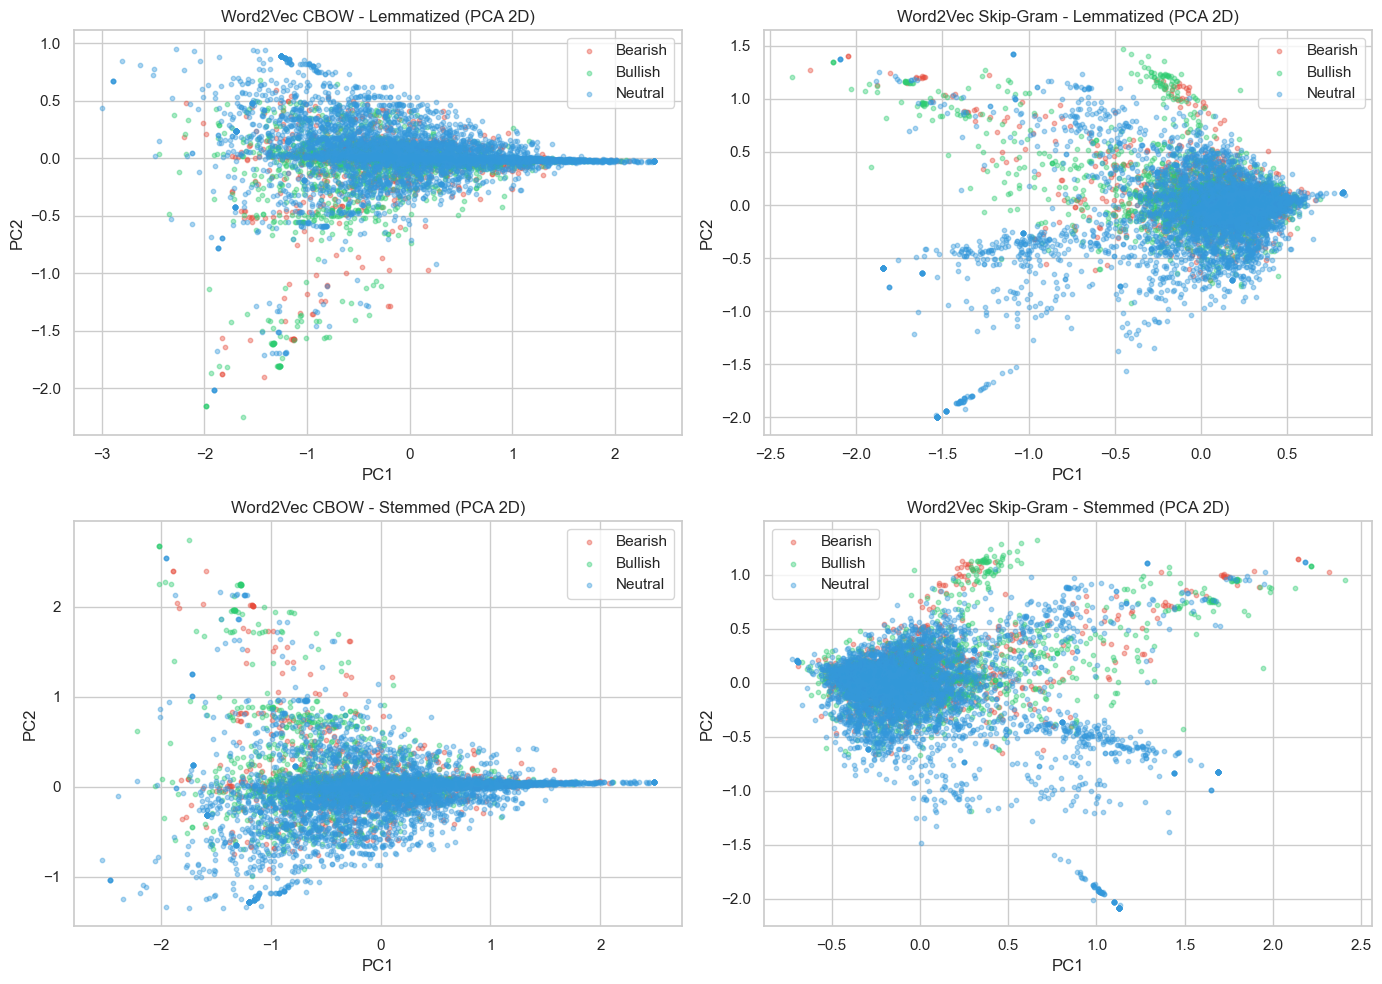

In [13]:
pca = PCA(n_components=2, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, embeddings, title in [
    (axes[0][0], x_train_cbow_lem,  'CBOW - Lemmatized'),
    (axes[0][1], x_train_sg_lem,    'Skip-Gram - Lemmatized'),
    (axes[1][0], x_train_cbow_stem, 'CBOW - Stemmed'),
    (axes[1][1], x_train_sg_stem,   'Skip-Gram - Stemmed'),
]:
    reduced = pca.fit_transform(embeddings)
    for label in [0, 1, 2]:
        mask = y_train == label
        ax.scatter(reduced[mask, 0], reduced[mask, 1],
                   label=LABEL_NAMES[label],
                   color=PALETTE[label], alpha=0.4, s=10)
    ax.set_title(f'Word2Vec {title} (PCA 2D)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend()

plt.tight_layout()
plt.show()

Both CBOW and Skip-Gram produce 100-dimensional dense vectors - a large reduction from the sparse BoW/TF-IDF vocabulary. The PCA projection shows how well the three sentiment classes separate in the embedding space. Overlapping regions indicate tweets whose embeddings are not discriminative - often Neutral tweets that share vocabulary with both Bearish and Bullish.

**Analysis of embedding quality:**

The similarity table reveals a consistent pattern: CBOW produces very high similarities for all pairs (~0.98–0.99), while Skip-Gram is more discriminative - `bullish`<->`bearish` drops to 0.72 and `gain`<->`loss` to 0.90. This suggests CBOW collapses too many vectors into a tight cluster, while Skip-Gram preserves more separation between semantically distinct words.

The word neighbourhood exploration confirms the corpus size limitation. `beat` and `miss` correctly cluster with `eps` and `revenue` (earnings context), but `bullish` and `bearish` attract unrelated words (`never`, `hedge`, `team`) - these terms are too infrequent in ~7,600 tweets to learn reliable representations from scratch. GloVe, trained on 2 billion tweets, should handle these significantly better.

<div id="6-glove" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">
    6. Pre-trained Embeddings - GloVe Twitter
  </h2>
</div>

Training Word2Vec from scratch on ~7,600 tweets produces low-quality embeddings - the corpus is too small to learn meaningful semantic relationships. **GloVe Twitter** was trained on **2 billion tweets** and produces much richer vectors.

GloVe differs from Word2Vec: instead of predicting context words, it factorises the global **word co-occurrence matrix** across the entire corpus.

We use `glove-twitter-100` (100-dimensional vectors, Twitter-trained) - particularly suited for our financial tweet corpus. Although GloVe Twitter inherits the informal language and biases of its training corpus, this is less of a concern here since our data is also Twitter-sourced.

In [14]:
print('Loading GloVe Twitter 100...')
glove = gensim.downloader.load('glove-twitter-100')
GLOVE_DIM = 100
print(f'Vocabulary size: {len(glove.index_to_key):,} words')

Loading GloVe Twitter 100...
Vocabulary size: 1,193,514 words


In [15]:
probe_words = ['beat', 'miss', 'bullish', 'bearish', 'upgrade', 'downgrade']

print('Most similar words in GloVe Twitter:')
print(f"{'Word':<15} {'GloVe most similar'}")
print('-' * 60)
for word in probe_words:
    if word in glove:
        similar = [w for w, _ in glove.most_similar(word, topn=3)]
        print(f'  {word:<15} -> {similar}')
    else:
        print(f'  {word:<15} -> NOT IN VOCABULARY')

Most similar words in GloVe Twitter:
Word            GloVe most similar
------------------------------------------------------------
  beat            -> ['play', 'beating', 'game']
  miss            -> ['love', 'wish', 'boo']
  bullish         -> ['bearish', 'technicals', 'divergence']
  bearish         -> ['bullish', 'technicals', 'divergence']
  upgrade         -> ['install', 'download', 'fix']
  downgrade       -> ['downgrading', 'downgrades', 'downgraded']


In [16]:
probe_bearish = ['miss', 'plunge', 'downgrade', 'cut', 'hedge']
probe_bullish = ['beat', 'price', 'target', 'raised', 'upgrade']
probe_neutral = ['dividend', 'earnings', 'conference', 'transcript', 'declares']

print('Most similar words in GloVe Twitter:')
print('-' * 60)
for group_name, probe_words in [('Bearish', probe_bearish),
                                  ('Bullish', probe_bullish),
                                  ('Neutral', probe_neutral)]:
    print(f'\n--- {group_name} ---')
    print(f"{'Word':<15} {'GloVe most similar'}")
    print('-' * 60)
    for word in probe_words:
        if word in glove:
            similar = [w for w, _ in glove.most_similar(word, topn=3)]
            print(f'  {word:<15} -> {similar}')
        else:
            print(f'  {word:<15} -> NOT IN VOCABULARY')

Most similar words in GloVe Twitter:
------------------------------------------------------------

--- Bearish ---
Word            GloVe most similar
------------------------------------------------------------
  miss            -> ['love', 'wish', 'boo']
  plunge          -> ['plummet', 'plunging', 'plunged']
  downgrade       -> ['downgrading', 'downgrades', 'downgraded']
  cut             -> ['cutting', 'cuts', 'put']
  hedge           -> ['equity', 'investors', 'trader']

--- Bullish ---
Word            GloVe most similar
------------------------------------------------------------
  beat            -> ['play', 'beating', 'game']
  price           -> ['prices', 'discount', 'deals']
  target          -> ['targets', 'bid', 'transfer']
  raised          -> ['raise', 'raising', 'brought']
  upgrade         -> ['install', 'download', 'fix']

--- Neutral ---
Word            GloVe most similar
------------------------------------------------------------
  dividend        -> ['dividends', 

In [17]:
def average_glove(texts, model, dim):
    vectors = []
    for text in texts:
        tokens = text.split()
        vecs   = [model[t] for t in tokens if t in model]
        vectors.append(np.mean(vecs, axis=0) if vecs else np.zeros(dim))
    return np.array(vectors)

print('Generating GloVe document vectors...')
x_train_glove_lem  = average_glove(x_train_lem,  glove, GLOVE_DIM)
x_val_glove_lem    = average_glove(x_val_lem,    glove, GLOVE_DIM)
test_glove_lem     = average_glove(test_lem,      glove, GLOVE_DIM)

x_train_glove_stem = average_glove(x_train_stem, glove, GLOVE_DIM)
x_val_glove_stem   = average_glove(x_val_stem,   glove, GLOVE_DIM)
test_glove_stem    = average_glove(test_stem,     glove, GLOVE_DIM)

for name, texts, vecs in [('lem', x_train_lem, x_train_glove_lem),
                           ('stem', x_train_stem, x_train_glove_stem)]:
    oov   = sum(1 for t in texts for w in t.split() if w not in glove)
    total = sum(len(t.split()) for t in texts)
    print(f'[{name}] shape: {vecs.shape}  |  OOV rate: {oov/total*100:.1f}%')

Generating GloVe document vectors...
[lem] shape: (7634, 100)  |  OOV rate: 12.1%
[stem] shape: (7634, 100)  |  OOV rate: 16.5%


GloVe embeddings are richer than our in-domain Word2Vec because they were trained on billions of tweets. However, financial acronyms and company names (e.g. `"EPS"`, `"BYND"`) may be OOV - these are simply skipped during averaging.

**Analysis:**

The OOV rate for the stemmed variant (16.5%) is significantly higher than for the lemmatized variant (12.1%) - stemming produces truncated forms (e.g. `"earn"`, `"announc"`) that GloVe has never seen, since it was trained on natural text. This is a meaningful disadvantage of stemming when using pre-trained embeddings: **lemmatization is the better choice for GloVe**.

The neighbourhood exploration shows a clear improvement over Word2Vec for domain-specific sentiment words: `bullish`<->`bearish` are each other's closest neighbour, and `bearish` correctly clusters with `technicals` and `divergence`. However, `beat` and `miss` still resolve to their general Twitter meanings (`play`, `game`, `love`) rather than financial ones - GloVe was trained on all tweets, not financial tweets specifically, so general usage dominates for ambiguous words.

### 6.3 PCA Visualisation - GloVe vs Word2Vec

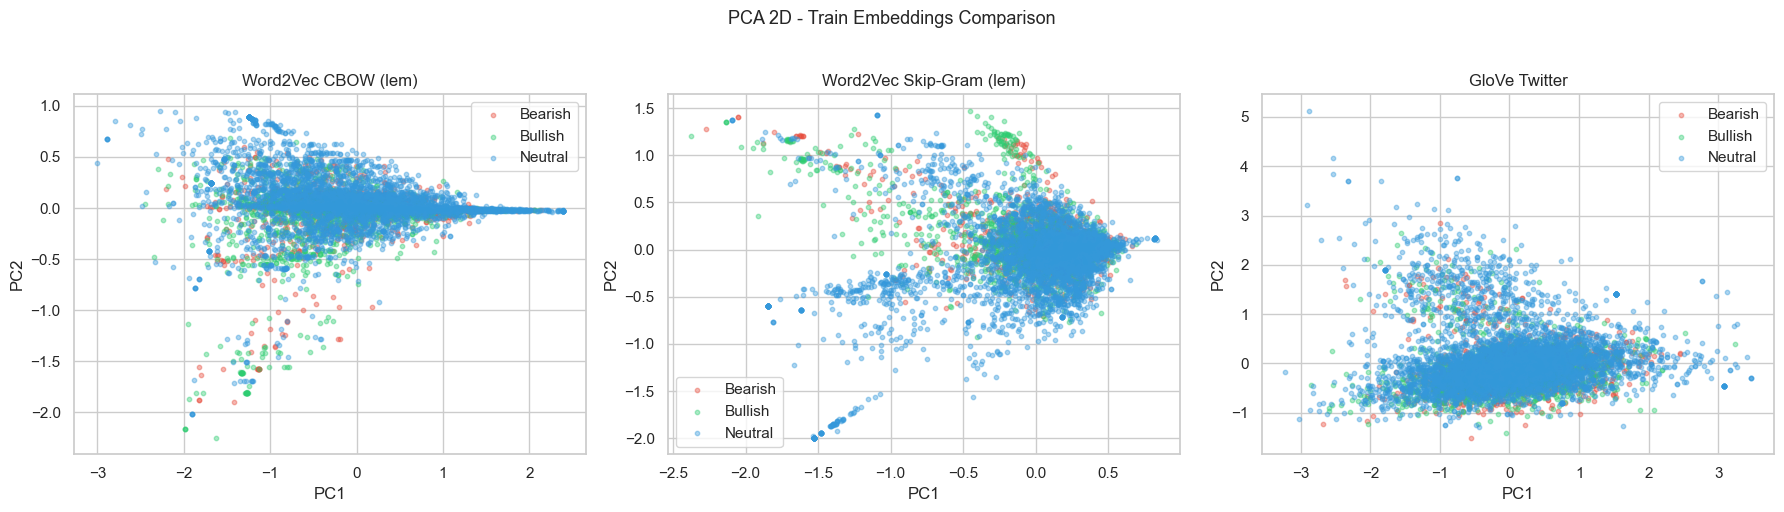

In [18]:
pca = PCA(n_components=2, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, embeddings, title in [
    (axes[0], x_train_cbow_lem,   'Word2Vec CBOW (lem)'),
    (axes[1], x_train_sg_lem,     'Word2Vec Skip-Gram (lem)'),
    (axes[2], x_train_glove_lem,  'GloVe Twitter'),
]:
    reduced = pca.fit_transform(embeddings)
    for label in [0, 1, 2]:
        mask = y_train == label
        ax.scatter(reduced[mask, 0], reduced[mask, 1],
                   label=LABEL_NAMES[label],
                   color=PALETTE[label], alpha=0.4, s=10)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend()

plt.suptitle('PCA 2D - Train Embeddings Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

All three models show significant class overlap in 2D - no clear separation between Bearish, Bullish, and Neutral. CBOW collapses into a narrow spike, suggesting degenerate vectors likely caused by the small corpus size. Skip-Gram and GloVe show a more spread distribution but classes remain mixed, confirming that average pooling loses the positional and contextual information needed to distinguish sentiment.

<div id="7-comparison" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">
    7. Representation Comparison
  </h2>
</div>

In [19]:
summary = pd.DataFrame([
    {'Representation': 'BoW Binary (lem)',       'Dimensions': x_train_bow_binary_lem.shape[1],  'Dense': False, 'Captures semantics': False},
    {'Representation': 'BoW Binary (stem)',      'Dimensions': x_train_bow_binary_stem.shape[1], 'Dense': False, 'Captures semantics': False},
    {'Representation': 'BoW Count (lem)',        'Dimensions': x_train_bow_count_lem.shape[1],   'Dense': False, 'Captures semantics': False},
    {'Representation': 'BoW Count (stem)',       'Dimensions': x_train_bow_count_stem.shape[1],  'Dense': False, 'Captures semantics': False},
    {'Representation': 'TF-IDF Unigrams (lem)',  'Dimensions': x_train_tfidf_uni_lem.shape[1],   'Dense': False, 'Captures semantics': False},
    {'Representation': 'TF-IDF Unigrams (stem)', 'Dimensions': x_train_tfidf_uni_stem.shape[1],  'Dense': False, 'Captures semantics': False},
    {'Representation': 'TF-IDF Bigrams (lem)',   'Dimensions': x_train_tfidf_bi_lem.shape[1],    'Dense': False, 'Captures semantics': 'Partial'},
    {'Representation': 'TF-IDF Bigrams (stem)',  'Dimensions': x_train_tfidf_bi_stem.shape[1],   'Dense': False, 'Captures semantics': 'Partial'},
    {'Representation': 'Word2Vec CBOW (lem)',    'Dimensions': W2V_DIM,                           'Dense': True,  'Captures semantics': True},
    {'Representation': 'Word2Vec CBOW (stem)',   'Dimensions': W2V_DIM,                           'Dense': True,  'Captures semantics': True},
    {'Representation': 'Word2Vec SG (lem)',      'Dimensions': W2V_DIM,                           'Dense': True,  'Captures semantics': True},
    {'Representation': 'Word2Vec SG (stem)',     'Dimensions': W2V_DIM,                           'Dense': True,  'Captures semantics': True},
    {'Representation': 'GloVe Twitter (lem)',    'Dimensions': GLOVE_DIM,                         'Dense': True,  'Captures semantics': True},
    {'Representation': 'GloVe Twitter (stem)',   'Dimensions': GLOVE_DIM,                         'Dense': True,  'Captures semantics': True},
])

print(summary.to_string(index=False))

        Representation  Dimensions  Dense Captures semantics
      BoW Binary (lem)       11113  False              False
     BoW Binary (stem)        9420  False              False
       BoW Count (lem)       11113  False              False
      BoW Count (stem)        9420  False              False
 TF-IDF Unigrams (lem)        5076  False              False
TF-IDF Unigrams (stem)        4501  False              False
  TF-IDF Bigrams (lem)       10468  False            Partial
 TF-IDF Bigrams (stem)       10151  False            Partial
   Word2Vec CBOW (lem)         100   True               True
  Word2Vec CBOW (stem)         100   True               True
     Word2Vec SG (lem)         100   True               True
    Word2Vec SG (stem)         100   True               True
   GloVe Twitter (lem)         100   True               True
  GloVe Twitter (stem)         100   True               True


<div id="8-save" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">
    8. Save Feature Matrices
  </h2>
</div>

In [20]:
os.makedirs('../data', exist_ok=True)

features = {
    # BoW
    'bow_binary_lem_train':  x_train_bow_binary_lem,
    'bow_binary_lem_val':    x_val_bow_binary_lem,
    'bow_binary_lem_test':   test_bow_binary_lem,
    'bow_binary_stem_train': x_train_bow_binary_stem,
    'bow_binary_stem_val':   x_val_bow_binary_stem,
    'bow_binary_stem_test':  test_bow_binary_stem,

    'bow_count_lem_train':   x_train_bow_count_lem,
    'bow_count_lem_val':     x_val_bow_count_lem,
    'bow_count_lem_test':    test_bow_count_lem,
    'bow_count_stem_train':  x_train_bow_count_stem,
    'bow_count_stem_val':    x_val_bow_count_stem,
    'bow_count_stem_test':   test_bow_count_stem,

    # TF-IDF
    'tfidf_uni_lem_train':   x_train_tfidf_uni_lem,
    'tfidf_uni_lem_val':     x_val_tfidf_uni_lem,
    'tfidf_uni_lem_test':    test_tfidf_uni_lem,
    'tfidf_uni_stem_train':  x_train_tfidf_uni_stem,
    'tfidf_uni_stem_val':    x_val_tfidf_uni_stem,
    'tfidf_uni_stem_test':   test_tfidf_uni_stem,

    'tfidf_bi_lem_train':    x_train_tfidf_bi_lem,
    'tfidf_bi_lem_val':      x_val_tfidf_bi_lem,
    'tfidf_bi_lem_test':     test_tfidf_bi_lem,
    'tfidf_bi_stem_train':   x_train_tfidf_bi_stem,
    'tfidf_bi_stem_val':     x_val_tfidf_bi_stem,
    'tfidf_bi_stem_test':    test_tfidf_bi_stem,

    # Word2Vec
    'w2v_cbow_lem_train':    x_train_cbow_lem,
    'w2v_cbow_lem_val':      x_val_cbow_lem,
    'w2v_cbow_lem_test':     test_cbow_lem,
    'w2v_cbow_stem_train':   x_train_cbow_stem,
    'w2v_cbow_stem_val':     x_val_cbow_stem,
    'w2v_cbow_stem_test':    test_cbow_stem,

    'w2v_sg_lem_train':      x_train_sg_lem,
    'w2v_sg_lem_val':        x_val_sg_lem,
    'w2v_sg_lem_test':       test_sg_lem,
    'w2v_sg_stem_train':     x_train_sg_stem,
    'w2v_sg_stem_val':       x_val_sg_stem,
    'w2v_sg_stem_test':      test_sg_stem,

    # GloVe
    'glove_lem_train':       x_train_glove_lem,
    'glove_lem_val':         x_val_glove_lem,
    'glove_lem_test':        test_glove_lem,
    'glove_stem_train':      x_train_glove_stem,
    'glove_stem_val':        x_val_glove_stem,
    'glove_stem_test':       test_glove_stem,

    # Labels
    'y_train':               y_train.to_numpy(),
    'y_val':                 y_val.to_numpy(),
}

with open('../data/features.pkl', 'wb') as f:
    pickle.dump(features, f)

print('Keys :', list(features.keys()))
print(f'Saved -> ../data/features.pkl')

Keys : ['bow_binary_lem_train', 'bow_binary_lem_val', 'bow_binary_lem_test', 'bow_binary_stem_train', 'bow_binary_stem_val', 'bow_binary_stem_test', 'bow_count_lem_train', 'bow_count_lem_val', 'bow_count_lem_test', 'bow_count_stem_train', 'bow_count_stem_val', 'bow_count_stem_test', 'tfidf_uni_lem_train', 'tfidf_uni_lem_val', 'tfidf_uni_lem_test', 'tfidf_uni_stem_train', 'tfidf_uni_stem_val', 'tfidf_uni_stem_test', 'tfidf_bi_lem_train', 'tfidf_bi_lem_val', 'tfidf_bi_lem_test', 'tfidf_bi_stem_train', 'tfidf_bi_stem_val', 'tfidf_bi_stem_test', 'w2v_cbow_lem_train', 'w2v_cbow_lem_val', 'w2v_cbow_lem_test', 'w2v_cbow_stem_train', 'w2v_cbow_stem_val', 'w2v_cbow_stem_test', 'w2v_sg_lem_train', 'w2v_sg_lem_val', 'w2v_sg_lem_test', 'w2v_sg_stem_train', 'w2v_sg_stem_val', 'w2v_sg_stem_test', 'glove_lem_train', 'glove_lem_val', 'glove_lem_test', 'glove_stem_train', 'glove_stem_val', 'glove_stem_test', 'y_train', 'y_val']
Saved -> ../data/features.pkl


### Save Sequential Embeddings (for RNN/LSTM in Notebook 04)

Build and save the sequential embeddings - word vectors **before averaging** - so notebook 04 can use them directly for RNN/BiRNN/LSTM without recomputing.

In [21]:
lens        = [len(doc.split()) for doc in x_train_lem]
p95         = int(np.percentile(lens, 95))
MAX_LEN_SEQ = max(lens)

print(f'Train sequence lengths — Max: {MAX_LEN_SEQ} | P95: {p95} | Median: {int(np.median(lens))}')
print(f'Using MAX_LEN_SEQ = {MAX_LEN_SEQ} (covers all tweets)')

def corpus2vec(corpus, model, dim):
    """Convert texts to list of word-vector sequences (no averaging)."""
    index_set = set(model.index_to_key)
    get_vec   = model.get_vector
    seqs = []
    for doc in tqdm(corpus, desc='Encoding'):
        vecs = [get_vec(w) for w in doc.split() if w in index_set]
        seqs.append(vecs if vecs else [np.zeros(dim)])
    return seqs

def build_sequences(texts_train, texts_val, texts_test, model, dim):
    return {
        'train': keras_pad(corpus2vec(texts_train, model, dim), maxlen=MAX_LEN_SEQ, padding='post', dtype='float32'),
        'val'  : keras_pad(corpus2vec(texts_val,   model, dim), maxlen=MAX_LEN_SEQ, padding='post', dtype='float32'),
        'test' : keras_pad(corpus2vec(texts_test,  model, dim), maxlen=MAX_LEN_SEQ, padding='post', dtype='float32'),
    }

print('Building W2V CBOW (lem)...')
seq_w2v_cbow_lem  = build_sequences(x_train_lem,  x_val_lem,  test_lem,  w2v_cbow_lem.wv,  W2V_DIM)

print('Building W2V SG (lem)...')
seq_w2v_sg_lem    = build_sequences(x_train_lem,  x_val_lem,  test_lem,  w2v_sg_lem.wv,    W2V_DIM)

print('Building W2V CBOW (stem)...')
seq_w2v_cbow_stem = build_sequences(x_train_stem, x_val_stem, test_stem, w2v_cbow_stem.wv, W2V_DIM)

print('Building W2V SG (stem)...')
seq_w2v_sg_stem   = build_sequences(x_train_stem, x_val_stem, test_stem, w2v_sg_stem.wv,   W2V_DIM)

print('Building GloVe (lem)...')
seq_glove_lem     = build_sequences(x_train_lem,  x_val_lem,  test_lem,  glove,            GLOVE_DIM)

print('Building GloVe (stem)...')
seq_glove_stem    = build_sequences(x_train_stem, x_val_stem, test_stem, glove,            GLOVE_DIM)

sequences = {
    'w2v_cbow_lem'  : seq_w2v_cbow_lem,
    'w2v_sg_lem'    : seq_w2v_sg_lem,
    'w2v_cbow_stem' : seq_w2v_cbow_stem,
    'w2v_sg_stem'   : seq_w2v_sg_stem,
    'glove_lem'     : seq_glove_lem,
    'glove_stem'    : seq_glove_stem,
}

with open('../data/sequences.pkl', 'wb') as f:
    pickle.dump(sequences, f)

print()
for name, seq in sequences.items():
    print(f'  {name:<20} — train: {seq["train"].shape} | val: {seq["val"].shape}')
print('Saved -> ../data/sequences.pkl')


Train sequence lengths — Max: 28 | P95: 14 | Median: 9
Using MAX_LEN_SEQ = 28 (covers all tweets)
Building W2V CBOW (lem)...


Encoding: 100%|██████████| 2388/2388 [00:00<00:00, 286638.18it/s]


Building W2V SG (lem)...


Encoding: 100%|██████████| 2388/2388 [00:00<00:00, 311142.80it/s]

Building W2V CBOW (stem)...

...

Building GloVe (lem)...


Encoding: 100%|██████████| 2388/2388 [00:00<00:00, 76994.61it/s]


Building GloVe (stem)...


Encoding: 100%|██████████| 2388/2388 [00:00<00:00, 81382.58it/s]



  w2v_cbow_lem         — train: (7634, 28, 100) | val: (1909, 28, 100)
  w2v_sg_lem           — train: (7634, 28, 100) | val: (1909, 28, 100)
  w2v_cbow_stem        — train: (7634, 28, 100) | val: (1909, 28, 100)
  w2v_sg_stem          — train: (7634, 28, 100) | val: (1909, 28, 100)
  glove_lem            — train: (7634, 28, 100) | val: (1909, 28, 100)
  glove_stem           — train: (7634, 28, 100) | val: (1909, 28, 100)
Saved -> ../data/sequences.pkl
